# 보고서 주장 vs 우리 데이터 검증

**목적**: 「한국 유기동물 관리 체계의 문제점 분석 및 주요 선진국과의 비교」 보고서의 핵심 주장을 Homebound 데이터(789,874건, 2019-2025)로 교차 검증한다.

**데이터 출처**: 보호종료동물 상세 데이터 → 전처리 완료된 집계 CSV 6종 활용

---

### 검증 대상 주장

| # | 보고서 주장 | 검증 방법 |
|---|-----------|----------|
| 1 | 유기동물 5년 연속 감소, 2024년 106,824마리 | 연도별 총 발생 건수 |
| 2 | 입양률 2021년 32.1% → 2024년 23.5% (3년 연속 하락) | 연도별 입양률 추이 |
| 3 | 안락사율 18.5%, 자연사 27.5% → 보호소 내 사망 46% | 종료사유별 비율 |
| 4 | 축종 비중: 개 72.4% / 고양이 26.0% (2024) | 축종별 비중 추이 |
| 5 | 믹스견·대형견 입양 시장에서 소외 | 품종별 입양률 비교 |
| 6 | 보호소 간 성과 극심한 격차 (위탁 구조 문제) | 보호소별 성과 분포 |
| 7 | 지역별 유기동물 관리 수준 격차 | 시도별 입양률·안락사율 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# 공통 색상 팔레트
COLORS = {
    '입양': '#2ecc71',
    '자연사': '#95a5a6',
    '안락사': '#e74c3c',
    '반환': '#3498db',
    '기타': '#f39c12',
    '개': '#e67e22',
    '고양이': '#9b59b6',
}

# 데이터 로드
DATA_DIR = '../02_outputs/data/'

monthly = pd.read_csv(f'{DATA_DIR}agg_monthly_outcome.csv')
region = pd.read_csv(f'{DATA_DIR}agg_region_yearly.csv')
breed = pd.read_csv(f'{DATA_DIR}agg_breed_adoption.csv')
shelter = pd.read_csv(f'{DATA_DIR}agg_shelter_performance.csv')
multidim = pd.read_csv(f'{DATA_DIR}agg_adoption_multidim.csv')
temporal = pd.read_csv(f'{DATA_DIR}agg_temporal_pattern.csv')

print('데이터 로드 완료')
print(f'  monthly:  {monthly.shape}')
print(f'  region:   {region.shape}')
print(f'  breed:    {breed.shape}')
print(f'  shelter:  {shelter.shape}')
print(f'  multidim: {multidim.shape}')
print(f'  temporal: {temporal.shape}')

데이터 로드 완료
  monthly:  (533, 4)
  region:   (119, 11)
  breed:    (216, 7)
  shelter:  (564, 14)
  multidim: (2795, 9)
  temporal: (2349, 7)


---
## 검증 1: 유기동물 발생 추이 — "5년 연속 감소, 2024년 106,824마리"

**보고서 주장**: 2024년 기준 국내 유실·유기동물 발생 수는 106,824마리로, 2017년 이후 7년 만에 11만 마리 미만으로 감소. 5년 연속 감소 추세.

In [2]:
# 연도별 총 발생 건수 산출
yearly_total = region.groupby('접수년도')['총건수'].sum().reset_index()
yearly_total.columns = ['연도', '총건수']
yearly_total['전년대비'] = yearly_total['총건수'].pct_change() * 100

print('=' * 60)
print('검증 1: 연도별 유기동물 발생 건수')
print('=' * 60)
print(yearly_total.to_string(index=False))
print()

# 보고서 vs 우리 데이터 비교
val_2024 = yearly_total[yearly_total['연도'] == 2024]['총건수'].values[0]
print(f'보고서: 2024년 106,824마리')
print(f'우리 데이터: 2024년 {val_2024:,.0f}마리')
print(f'차이: {val_2024 - 106824:+,.0f}마리 ({(val_2024 - 106824) / 106824 * 100:+.1f}%)')

# 5년 연속 감소 확인
changes = yearly_total[yearly_total['연도'].between(2020, 2024)]['전년대비']
consecutive_decrease = all(changes < 0)
print(f'\n5년 연속 감소(2020-2024): {"✓ 확인" if consecutive_decrease else "✗ 불일치"}')

검증 1: 연도별 유기동물 발생 건수
  연도    총건수       전년대비
2019 133429        NaN
2020 128717  -3.531466
2021 116568  -9.438536
2022 111672  -4.200124
2023 110717  -0.855183
2024 103282  -6.715319
2025  85489 -17.227590

보고서: 2024년 106,824마리
우리 데이터: 2024년 103,282마리
차이: -3,542마리 (-3.3%)

5년 연속 감소(2020-2024): ✓ 확인


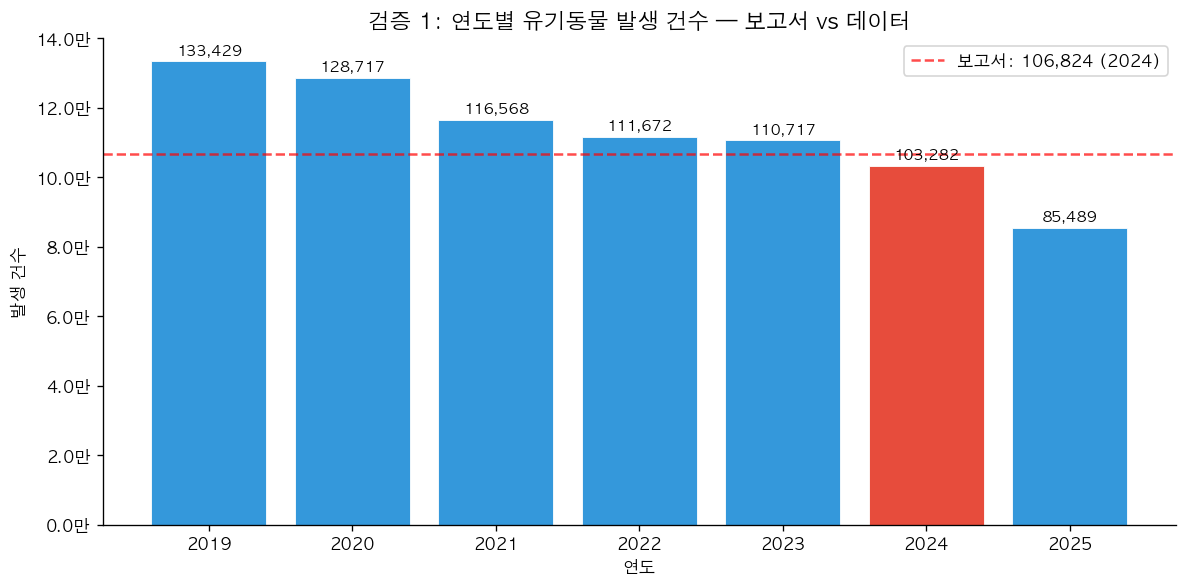

In [3]:
# 시각화: 연도별 발생 추이
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(yearly_total['연도'], yearly_total['총건수'], 
              color=['#3498db' if y != 2024 else '#e74c3c' for y in yearly_total['연도']],
              edgecolor='white', linewidth=0.5)

# 값 표시
for bar, val in zip(bars, yearly_total['총건수']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 보고서 수치 표시
ax.axhline(y=106824, color='red', linestyle='--', alpha=0.7, label='보고서: 106,824 (2024)')

ax.set_xlabel('연도')
ax.set_ylabel('발생 건수')
ax.set_title('검증 1: 연도별 유기동물 발생 건수 — 보고서 vs 데이터', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/10000:.1f}만'))
ax.set_xticks(yearly_total['연도'])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../02_outputs/figures/검증1_발생추이.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 2: 입양률 하락 추이 — "2021년 32.1% → 2024년 23.5%"

**보고서 주장**: 입양률은 2021년 32.1%를 기점으로 3년 연속 하락하여 2024년 23.5%까지 떨어졌다.

In [4]:
# 연도별 종료사유별 건수 집계
yearly_outcome = monthly.groupby(['접수년도', '종료사유_정제'])['건수'].sum().reset_index()
yearly_total_outcome = yearly_outcome.groupby('접수년도')['건수'].sum().reset_index()
yearly_total_outcome.columns = ['접수년도', '총건수']

yearly_outcome = yearly_outcome.merge(yearly_total_outcome, on='접수년도')
yearly_outcome['비율'] = (yearly_outcome['건수'] / yearly_outcome['총건수'] * 100).round(2)

# 주요 종료사유별 연도별 비율
pivot = yearly_outcome.pivot_table(index='접수년도', columns='종료사유_정제', values='비율', fill_value=0)

print('=' * 60)
print('검증 2: 연도별 종료사유 비율 (%)')
print('=' * 60)
print(pivot[['입양', '자연사', '안락사', '반환']].round(1).to_string())
print()

# 보고서 vs 데이터 비교 (2024년)
report_vals = {'입양': 23.5, '안락사': 18.5, '자연사': 27.5, '반환': 11.4}
data_vals_2024 = pivot.loc[2024][['입양', '안락사', '자연사', '반환']]

print('\n2024년 비교 (보고서 vs 데이터):')
print(f'{"종료사유":<8} {"보고서":>8} {"데이터":>8} {"차이":>8}')
print('-' * 36)
for key in report_vals:
    diff = data_vals_2024[key] - report_vals[key]
    print(f'{key:<8} {report_vals[key]:>7.1f}% {data_vals_2024[key]:>7.1f}% {diff:>+7.1f}%p')

# 입양률 2021→2024 하락 확인
adoption_2021 = pivot.loc[2021, '입양']
adoption_2024 = pivot.loc[2024, '입양']
print(f'\n입양률 추이: {adoption_2021:.1f}%(2021) → {adoption_2024:.1f}%(2024) = {adoption_2024 - adoption_2021:+.1f}%p')
print(f'보고서 주장 (32.1% → 23.5%): ', end='')

# 3년 연속 하락 확인
adoption_series = pivot['입양'].loc[2021:2024]
consecutive_drop = all(adoption_series.diff().dropna() < 0)
print(f'3년 연속 하락 {"✓ 확인" if consecutive_drop else "✗ 불일치"}')

검증 2: 연도별 종료사유 비율 (%)
종료사유_정제    입양   자연사   안락사    반환
접수년도                           
2019     30.2  29.0  25.7  12.3
2020     33.9  27.9  23.8  11.6
2021     36.4  28.6  19.8  12.2
2022     31.2  30.0  21.4  12.6
2023     27.8  30.8  23.3  12.3
2024     27.7  30.1  23.7  11.8
2025     30.5  28.9  20.7  12.5


2024년 비교 (보고서 vs 데이터):
종료사유          보고서      데이터       차이
------------------------------------
입양          23.5%    27.7%    +4.2%p
안락사         18.5%    23.7%    +5.2%p
자연사         27.5%    30.1%    +2.6%p
반환          11.4%    11.8%    +0.4%p

입양률 추이: 36.4%(2021) → 27.7%(2024) = -8.7%p
보고서 주장 (32.1% → 23.5%): 3년 연속 하락 ✓ 확인


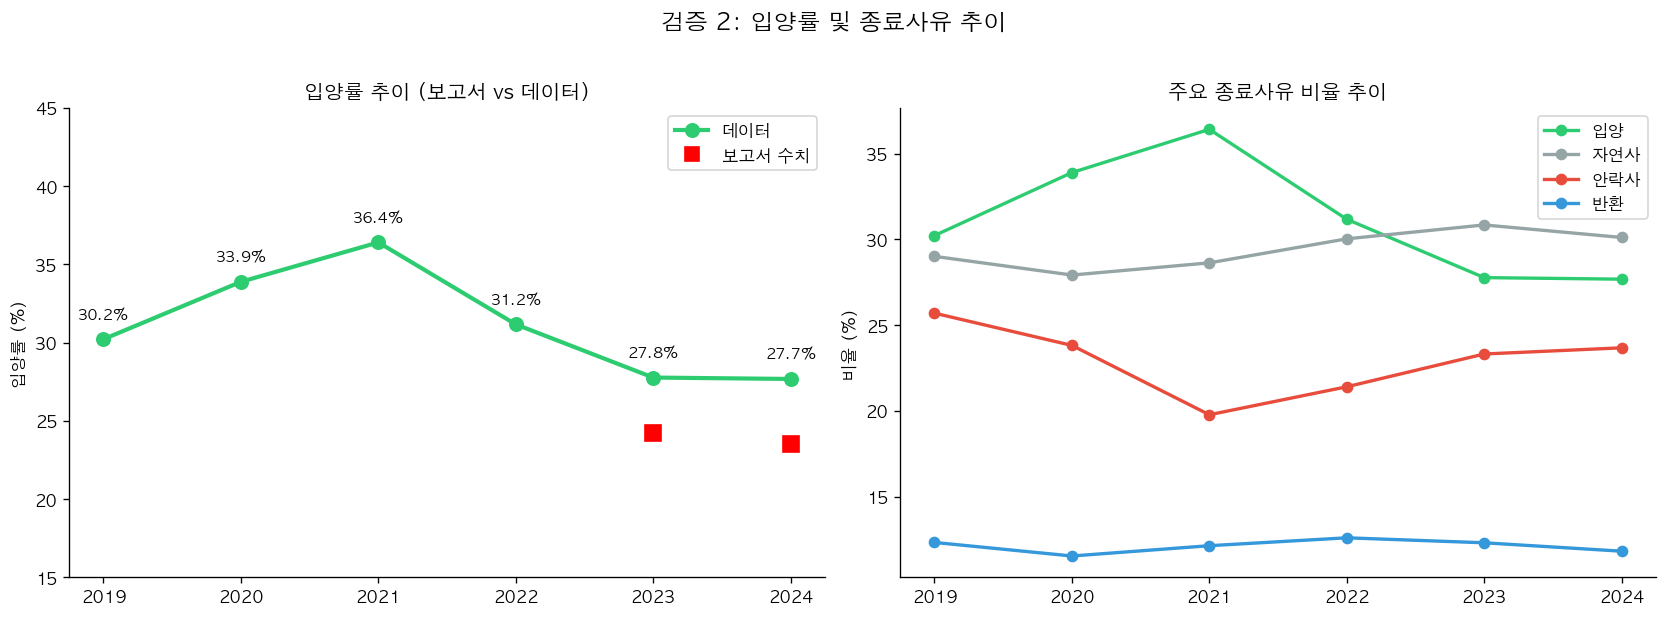

In [5]:
# 시각화: 종료사유 비율 추이
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 입양률 추이 (보고서 비교)
ax = axes[0]
years = pivot.index[:-1]  # 2025 제외 (미완료 연도)
ax.plot(years, pivot.loc[years, '입양'], 'o-', color=COLORS['입양'], 
        linewidth=2.5, markersize=8, label='데이터', zorder=5)

# 보고서 수치 포인트
report_points = {2023: 24.2, 2024: 23.5}
for yr, val in report_points.items():
    ax.plot(yr, val, 's', color='red', markersize=10, zorder=6)
ax.plot([], [], 's', color='red', markersize=8, label='보고서 수치')

for yr in years:
    ax.annotate(f'{pivot.loc[yr, "입양"]:.1f}%', (yr, pivot.loc[yr, '입양']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

ax.set_title('입양률 추이 (보고서 vs 데이터)', fontweight='bold')
ax.set_ylabel('입양률 (%)')
ax.set_xticks(years)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(15, 45)

# 우: 4대 종료사유 추이
ax = axes[1]
for cause in ['입양', '자연사', '안락사', '반환']:
    color = COLORS.get(cause, '#333')
    ax.plot(years, pivot.loc[years, cause], 'o-', color=color, 
            linewidth=2, markersize=6, label=cause)

ax.set_title('주요 종료사유 비율 추이', fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xticks(years)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('검증 2: 입양률 및 종료사유 추이', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../02_outputs/figures/검증2_입양률추이.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 3: 보호소 내 사망률 — "자연사 27.5% + 안락사 18.5% = 약 46%"

**보고서 주장**: 입소 동물의 약 46%가 보호소 내에서 자연사하거나 안락사로 생을 마감한다.

In [6]:
# 연도별 보호소 내 사망률 (자연사 + 안락사)
death_in_shelter = pivot[['자연사', '안락사']].copy()
death_in_shelter['합계(사망률)'] = death_in_shelter['자연사'] + death_in_shelter['안락사']

print('=' * 60)
print('검증 3: 연도별 보호소 내 사망률 (자연사 + 안락사)')
print('=' * 60)
print(death_in_shelter.round(1).to_string())
print()

val_2024 = death_in_shelter.loc[2024, '합계(사망률)']
print(f'보고서: 2024년 약 46% (자연사 27.5% + 안락사 18.5%)')
print(f'데이터: 2024년 {val_2024:.1f}% (자연사 {death_in_shelter.loc[2024, "자연사"]:.1f}% + 안락사 {death_in_shelter.loc[2024, "안락사"]:.1f}%)')
print(f'\n→ 보호소에 들어온 동물 {"2마리 중 1마리" if val_2024 > 45 else "약 절반"}가 보호소에서 죽는다')

검증 3: 연도별 보호소 내 사망률 (자연사 + 안락사)
종료사유_정제   자연사   안락사  합계(사망률)
접수년도                        
2019     29.0  25.7     54.7
2020     27.9  23.8     51.7
2021     28.6  19.8     48.4
2022     30.0  21.4     51.4
2023     30.8  23.3     54.2
2024     30.1  23.7     53.8
2025     28.9  20.7     49.6

보고서: 2024년 약 46% (자연사 27.5% + 안락사 18.5%)
데이터: 2024년 53.8% (자연사 30.1% + 안락사 23.7%)

→ 보호소에 들어온 동물 2마리 중 1마리가 보호소에서 죽는다


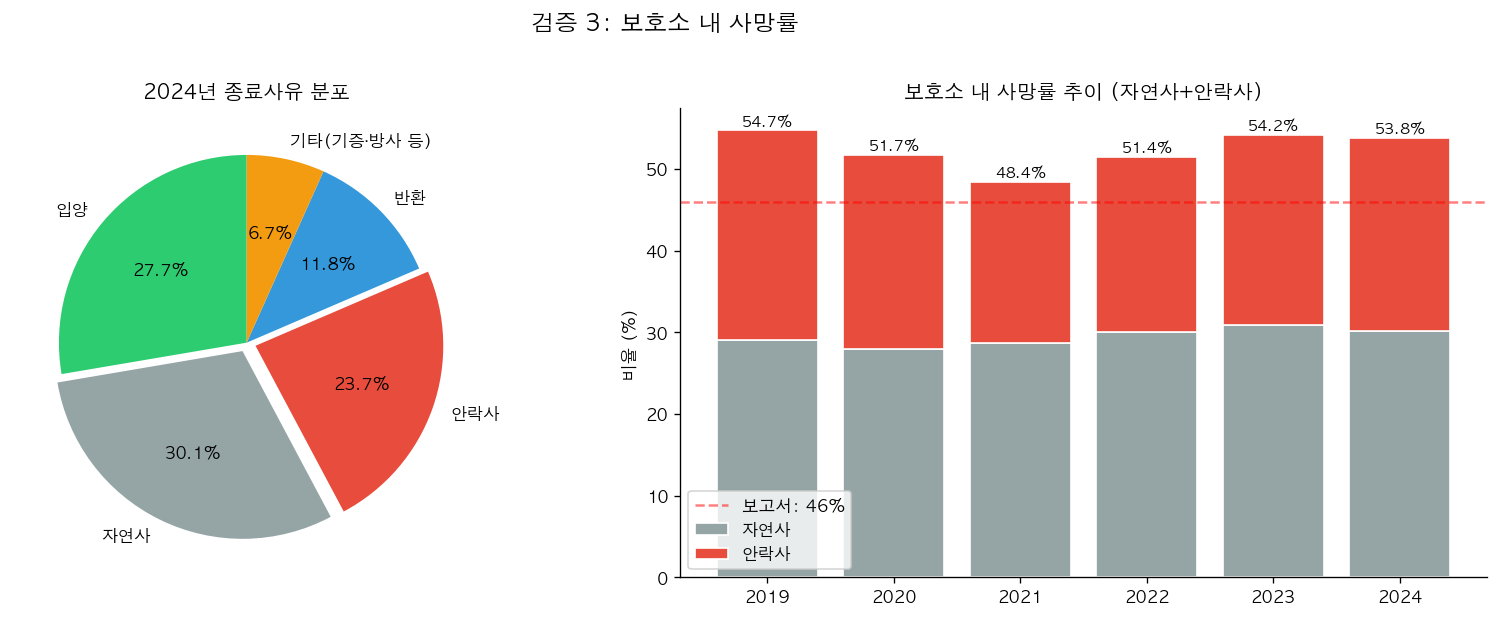

In [7]:
# 시각화: 2024년 종료사유 파이차트 + 연도별 사망률 추이
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 2024년 종료사유 파이차트
ax = axes[0]
data_2024 = yearly_outcome[yearly_outcome['접수년도'] == 2024].set_index('종료사유_정제')['건수']
# 주요 4개 + 기타 통합
main_causes = ['입양', '자연사', '안락사', '반환']
pie_data = data_2024[main_causes].copy()
pie_data['기타(기증·방사 등)'] = data_2024.drop(main_causes, errors='ignore').sum()

colors_pie = [COLORS['입양'], COLORS['자연사'], COLORS['안락사'], COLORS['반환'], COLORS['기타']]
explode = (0, 0.05, 0.05, 0, 0)  # 사망 강조

wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_data.index, autopct='%1.1f%%',
    colors=colors_pie, explode=explode, startangle=90,
    textprops={'fontsize': 10})
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('2024년 종료사유 분포', fontweight='bold')

# 우: 연도별 사망률 스택 바
ax = axes[1]
years_plot = death_in_shelter.index[:-1]  # 2025 제외
ax.bar(years_plot, death_in_shelter.loc[years_plot, '자연사'], 
       color=COLORS['자연사'], label='자연사', edgecolor='white')
ax.bar(years_plot, death_in_shelter.loc[years_plot, '안락사'], 
       bottom=death_in_shelter.loc[years_plot, '자연사'],
       color=COLORS['안락사'], label='안락사', edgecolor='white')

for yr in years_plot:
    total = death_in_shelter.loc[yr, '합계(사망률)']
    ax.text(yr, total + 0.5, f'{total:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=46, color='red', linestyle='--', alpha=0.5, label='보고서: 46%')
ax.set_title('보호소 내 사망률 추이 (자연사+안락사)', fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xticks(years_plot)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('검증 3: 보호소 내 사망률', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../02_outputs/figures/검증3_사망률.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 4: 축종 비중 — "개 72.4% / 고양이 26.0% (2024)"

**보고서 주장**: 2024년 기준 축종별 비중은 개 72.4%, 고양이 26.0%이며 개의 비중이 소폭 상승 중.

In [8]:
# 지역별 연도별 데이터에서 축종 비중 계산
species_yearly = region.groupby('접수년도')[['총건수', '개_건수', '고양이_건수']].sum().reset_index()
species_yearly['기타_건수'] = species_yearly['총건수'] - species_yearly['개_건수'] - species_yearly['고양이_건수']
species_yearly['개_비중'] = (species_yearly['개_건수'] / species_yearly['총건수'] * 100).round(1)
species_yearly['고양이_비중'] = (species_yearly['고양이_건수'] / species_yearly['총건수'] * 100).round(1)
species_yearly['기타_비중'] = (species_yearly['기타_건수'] / species_yearly['총건수'] * 100).round(1)

print('=' * 60)
print('검증 4: 연도별 축종 비중')
print('=' * 60)
print(species_yearly[['접수년도', '총건수', '개_비중', '고양이_비중', '기타_비중']].to_string(index=False))
print()

# 2024년 비교
row_2024 = species_yearly[species_yearly['접수년도'] == 2024].iloc[0]
print(f'보고서: 개 72.4% / 고양이 26.0%')
print(f'데이터: 개 {row_2024["개_비중"]}% / 고양이 {row_2024["고양이_비중"]}%')

검증 4: 연도별 축종 비중
 접수년도    총건수  개_비중  고양이_비중  기타_비중
 2019 133429  74.1    21.5    4.4
 2020 128717  72.0    23.7    4.2
 2021 116568  71.0    26.1    2.9
 2022 111672  70.5    27.1    2.4
 2023 110717  71.1    26.8    2.2
 2024 103282  72.1    25.5    2.4
 2025  85489  68.6    29.1    2.3

보고서: 개 72.4% / 고양이 26.0%
데이터: 개 72.1% / 고양이 25.5%


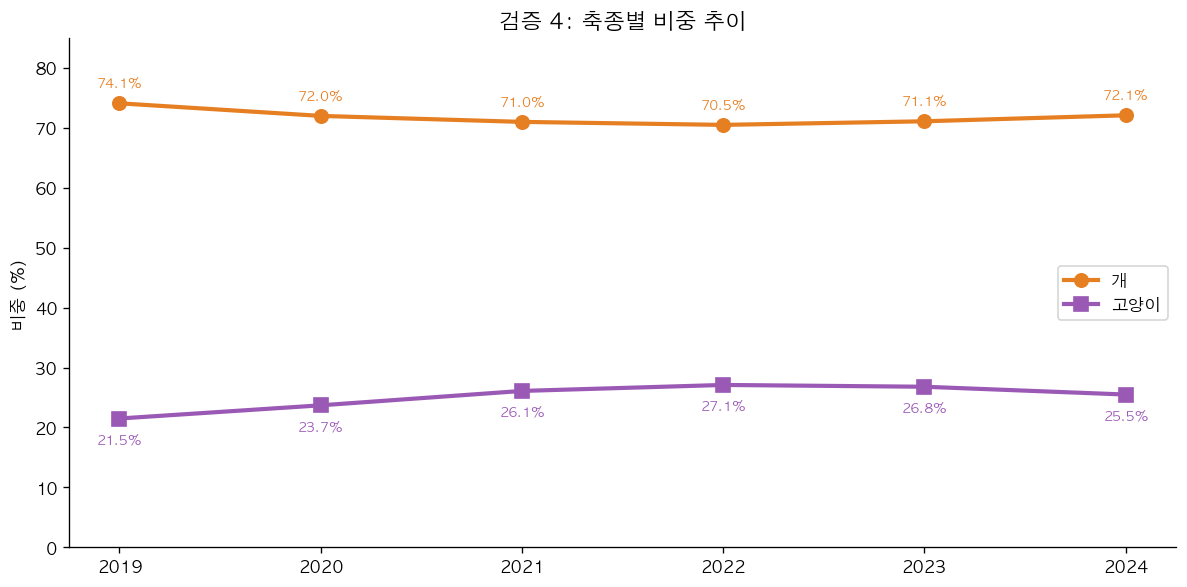

In [9]:
# 시각화: 축종 비중 추이
fig, ax = plt.subplots(figsize=(10, 5))

years_plot = species_yearly[species_yearly['접수년도'] <= 2024]['접수년도']
ax.plot(years_plot, species_yearly[species_yearly['접수년도'] <= 2024]['개_비중'], 
        'o-', color=COLORS['개'], linewidth=2.5, markersize=8, label='개')
ax.plot(years_plot, species_yearly[species_yearly['접수년도'] <= 2024]['고양이_비중'], 
        's-', color=COLORS['고양이'], linewidth=2.5, markersize=8, label='고양이')

for yr in years_plot:
    row = species_yearly[species_yearly['접수년도'] == yr].iloc[0]
    ax.annotate(f'{row["개_비중"]}%', (yr, row['개_비중']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color=COLORS['개'])
    ax.annotate(f'{row["고양이_비중"]}%', (yr, row['고양이_비중']),
                textcoords='offset points', xytext=(0, -15), ha='center', fontsize=8, color=COLORS['고양이'])

ax.set_title('검증 4: 축종별 비중 추이', fontsize=13, fontweight='bold')
ax.set_ylabel('비중 (%)')
ax.set_xticks(years_plot)
ax.legend(loc='center right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 85)

plt.tight_layout()
plt.savefig('../02_outputs/figures/검증4_축종비중.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 5: 믹스견·대형견 입양 소외 — "입양 시장에서 철저히 소외"

**보고서 주장**:
- 유기동물의 대다수를 차지하는 믹스견과 대형견은 국내 입양 시장에서 철저히 소외
- 아파트 중심 주거문화와 '품종견' 선호 사회적 편견이 원인
- 독일은 믹스견을 개성 있는 개체로 인식하고 대형견 입양 프로그램이 잘 갖춰짐

In [10]:
# 품종별 입양률 (개만 필터, 총건수 1000건 이상)
breed_dog = breed[(breed['동물종류'] == '개') & (breed['총건수'] >= 1000)].copy()
breed_dog = breed_dog.sort_values('입양률', ascending=True)

# 믹스견 vs 품종견 비교
mix_row = breed_dog[breed_dog['품종'] == '믹스견'].iloc[0]
purebred = breed_dog[breed_dog['품종'] != '믹스견']

print('=' * 60)
print('검증 5: 믹스견 vs 품종견 입양률 비교 (1,000건 이상 품종)')
print('=' * 60)
print(f'\n믹스견: 입양률 {mix_row["입양률"]:.1f}% (총 {mix_row["총건수"]:,.0f}건, 평균체중 {mix_row["평균체중"]:.1f}kg)')
print(f'품종견 평균 입양률: {purebred["입양률"].mean():.1f}%')
print(f'격차: {purebred["입양률"].mean() - mix_row["입양률"]:.1f}%p\n')

print(f'{"품종":<20} {"총건수":>8} {"입양률":>8} {"평균체중":>8}')
print('-' * 48)
for _, row in breed_dog.iterrows():
    marker = ' ◀ 믹스견' if row['품종'] == '믹스견' else ''
    print(f'{row["품종"]:<20} {row["총건수"]:>8,.0f} {row["입양률"]:>7.1f}% {row["평균체중"]:>7.1f}kg{marker}')

# 체중(대형견 지표)별 입양률
print('\n\n--- 체중 구간별 입양률 (대형견 소외 검증) ---')
weight_adoption = multidim[multidim['동물종류'] == '개'].groupby('시도').apply(
    lambda x: pd.Series({'총건수': x['총건수'].sum(), '입양건수': x['입양건수'].sum()})
).reset_index()

# 체중별 분석은 breed 데이터의 평균체중 활용
breed_dog['체중구간'] = pd.cut(breed_dog['평균체중'], bins=[0, 5, 10, 20, 100],
                              labels=['소형(~5kg)', '중형(5~10kg)', '중대형(10~20kg)', '대형(20kg~)'])
weight_group = breed_dog.groupby('체중구간', observed=True).agg(
    총건수=('총건수', 'sum'),
    입양건수=('입양건수', 'sum')
).reset_index()
weight_group['입양률'] = (weight_group['입양건수'] / weight_group['총건수'] * 100).round(1)
print(weight_group.to_string(index=False))

검증 5: 믹스견 vs 품종견 입양률 비교 (1,000건 이상 품종)

믹스견: 입양률 27.7% (총 420,511건, 평균체중 6.4kg)
품종견 평균 입양률: 36.4%
격차: 8.8%p

품종                        총건수      입양률     평균체중
------------------------------------------------
믹스견                   420,511    27.7%     6.4kg ◀ 믹스견
슈나우져                    1,131    28.3%     6.6kg
요크셔 테리어                 4,001    29.6%     3.5kg
시베리안 허스키                2,568    30.0%    19.6kg
시바                      3,188    30.3%     9.3kg
라브라도 리트리버               5,161    30.6%    25.1kg
골든 리트리버                 4,195    31.8%    25.4kg
진도견                    14,445    32.1%    13.3kg
미니어쳐 핀셔                 1,383    33.3%     4.4kg
보더 콜리                   2,442    35.1%    15.6kg
시츄                      6,344    35.8%     5.0kg
말티즈                    23,808    36.1%     3.6kg
보스턴 테리어                 1,117    36.7%     7.3kg
스피츠                     4,307    37.0%     6.5kg
프렌치 불독                  2,940    37.6%     9.3kg
비글                      1,106    39.1%    10.0kg
코카 스

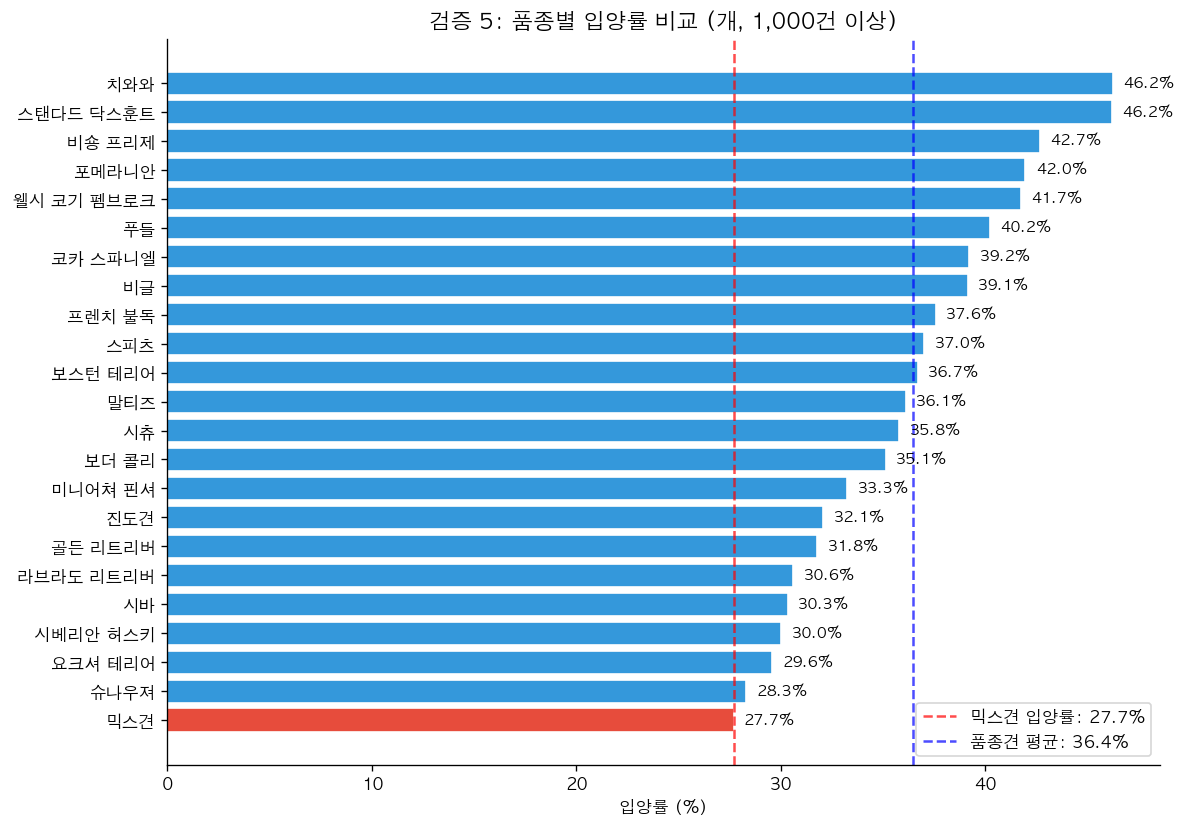

In [11]:
# 시각화: 품종별 입양률 수평 막대
fig, ax = plt.subplots(figsize=(10, 7))

colors_bar = ['#e74c3c' if p == '믹스견' else '#3498db' for p in breed_dog['품종']]
bars = ax.barh(breed_dog['품종'], breed_dog['입양률'], color=colors_bar, edgecolor='white')

# 값 표시
for bar, val in zip(bars, breed_dog['입양률']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# 믹스견 평균선
ax.axvline(x=mix_row['입양률'], color='red', linestyle='--', alpha=0.7, 
           label=f'믹스견 입양률: {mix_row["입양률"]:.1f}%')
ax.axvline(x=purebred['입양률'].mean(), color='blue', linestyle='--', alpha=0.7,
           label=f'품종견 평균: {purebred["입양률"].mean():.1f}%')

ax.set_xlabel('입양률 (%)')
ax.set_title('검증 5: 품종별 입양률 비교 (개, 1,000건 이상)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../02_outputs/figures/검증5_품종별입양률.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 6: 보호소 성과 양극화 — "위탁 구조의 수익성 ↔ 열악한 보호"

**보고서 주장**:
- 국내 보호소의 약 67%는 민간 위탁으로 운영
- 마릿수 기반 보조금 → 비용 절감 인센티브 → 동물 식단·의료·사회화 교육 최소화
- 결과적으로 보호소 내 전염병 확산과 자연사 비율(27.5%) 증가

In [12]:
# 보호소별 성과 분포 (총보호 100건 이상만)
shelter_valid = shelter[shelter['총보호건수'] >= 100].copy()

print('=' * 60)
print('검증 6: 보호소 성과 분포 (100건 이상 보호소)')
print('=' * 60)
print(f'분석 대상 보호소 수: {len(shelter_valid)}개\n')

for col, label in [('입양률', '입양률'), ('안락사율', '안락사율'), ('자연사율', '자연사율')]:
    print(f'[{label}]')
    print(f'  최소: {shelter_valid[col].min():.1f}% ({shelter_valid.loc[shelter_valid[col].idxmin(), "보호소명"]})')
    print(f'  중앙값: {shelter_valid[col].median():.1f}%')
    print(f'  평균: {shelter_valid[col].mean():.1f}%')
    print(f'  최대: {shelter_valid[col].max():.1f}% ({shelter_valid.loc[shelter_valid[col].idxmax(), "보호소명"]})')
    print(f'  IQR: {shelter_valid[col].quantile(0.25):.1f}% ~ {shelter_valid[col].quantile(0.75):.1f}%')
    print()

# 상위/하위 5개 보호소
print('--- 입양률 상위 5개 ---')
top5 = shelter_valid.nlargest(5, '입양률')[['보호소명', '시도', '총보호건수', '입양률', '안락사율', '자연사율']]
print(top5.to_string(index=False))
print('\n--- 입양률 하위 5개 ---')
bot5 = shelter_valid.nsmallest(5, '입양률')[['보호소명', '시도', '총보호건수', '입양률', '안락사율', '자연사율']]
print(bot5.to_string(index=False))

검증 6: 보호소 성과 분포 (100건 이상 보호소)
분석 대상 보호소 수: 388개

[입양률]
  최소: 1.7% (녹십자동물병원)
  중앙값: 30.5%
  평균: 33.9%
  최대: 93.3% (대구시수의사회(동산))


  IQR: 21.6% ~ 43.0%

[안락사율]
  최소: 0.0% (속초시유기동물보호소)
  중앙값: 16.4%
  평균: 21.7%
  최대: 98.1% (녹십자동물병원)
  IQR: 5.3% ~ 33.1%

[자연사율]
  최소: 0.0% (녹십자동물병원)
  중앙값: 26.0%
  평균: 28.0%
  최대: 79.7% (사천시위탁관리소)
  IQR: 16.2% ~ 35.7%

--- 입양률 상위 5개 ---
       보호소명    시도  총보호건수   입양률  안락사율  자연사율
대구시수의사회(동산) 대구광역시    682 93.26  0.00  6.60
 구리시 반려돌봄센터   경기도    101 91.09  0.00  3.96
대구시수의사회(삼성) 대구광역시   1007 83.71  0.99 10.03
     멘토동물병원 대구광역시    609 82.10  0.00 12.97
    행복한동물병원   경기도    327 81.96  5.20  2.45

--- 입양률 하위 5개 ---
      보호소명      시도  총보호건수  입양률  안락사율  자연사율
   녹십자동물병원    충청남도    362 1.66 98.07  0.00
유기동물임시보호센터    전라남도   1954 5.68 25.69 65.30
     원동물병원 전북특별자치도    176 6.82 41.48 47.16
   더나은동물병원 전북특별자치도   1434 6.90 56.90 31.94
화순군유기동물보호소    전라남도   1266 7.19 16.27 67.38


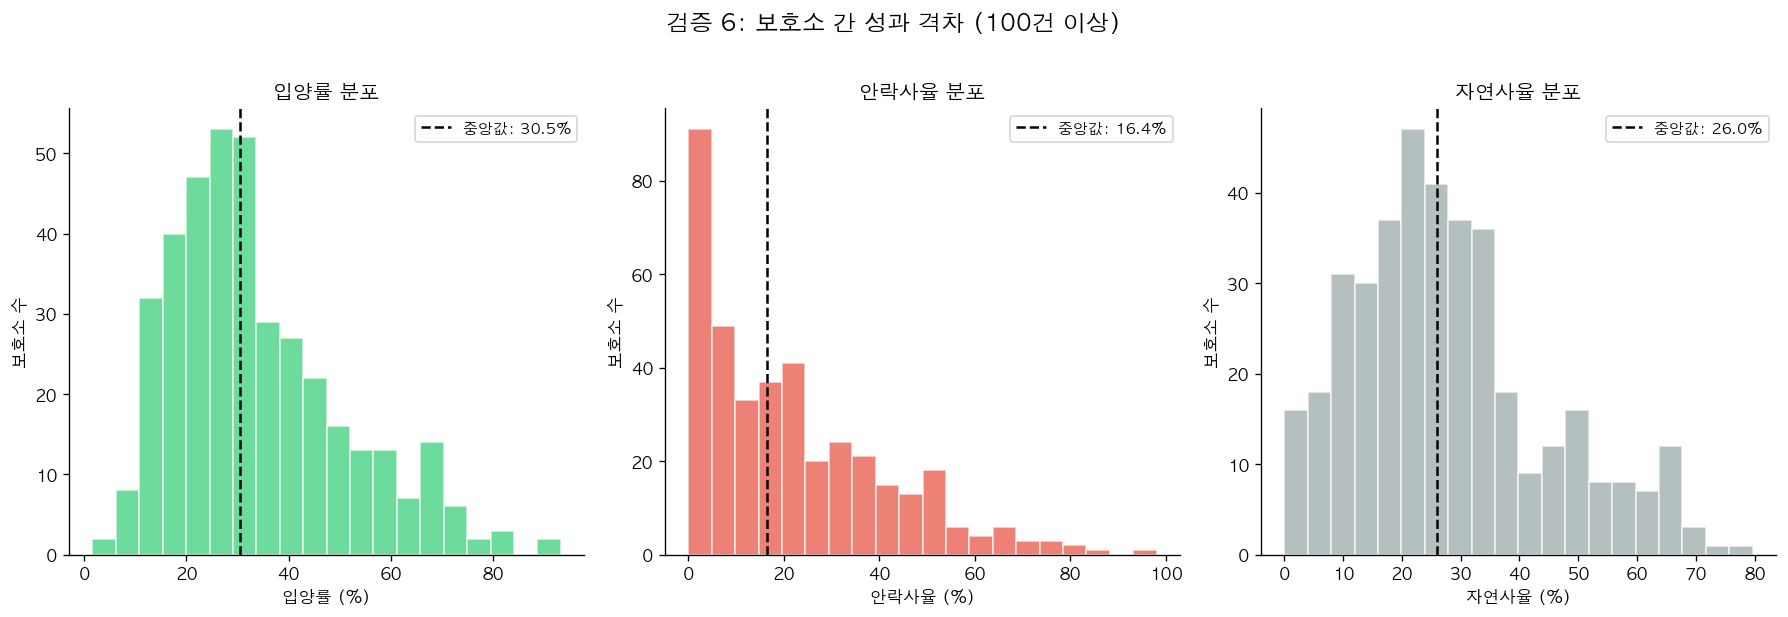

In [13]:
# 시각화: 보호소 성과 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('입양률', COLORS['입양']), ('안락사율', COLORS['안락사']), ('자연사율', COLORS['자연사'])]

for ax, (metric, color) in zip(axes, metrics):
    ax.hist(shelter_valid[metric], bins=20, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(shelter_valid[metric].median(), color='black', linestyle='--', 
               label=f'중앙값: {shelter_valid[metric].median():.1f}%')
    ax.set_title(f'{metric} 분포', fontweight='bold')
    ax.set_xlabel(f'{metric} (%)')
    ax.set_ylabel('보호소 수')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('검증 6: 보호소 간 성과 격차 (100건 이상)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../02_outputs/figures/검증6_보호소격차.png', dpi=150, bbox_inches='tight')
plt.show()

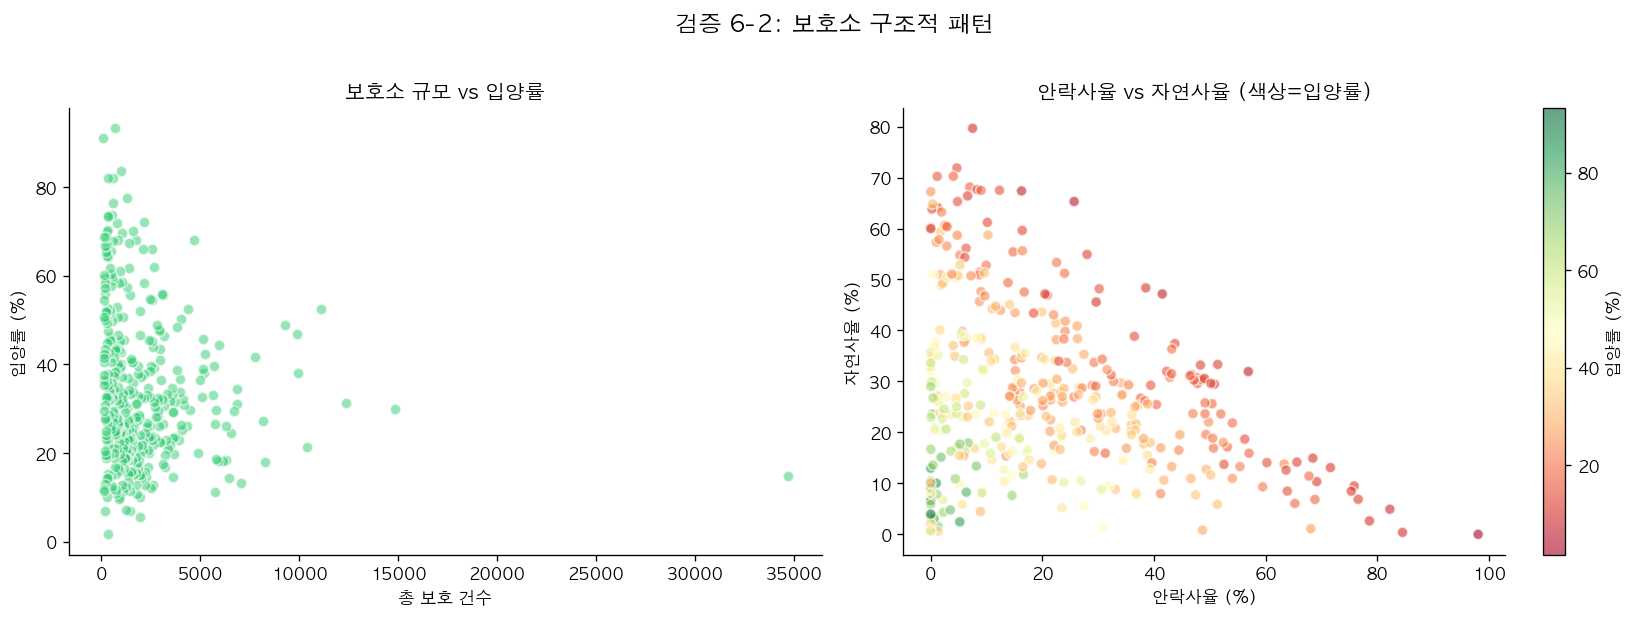

In [14]:
# 보호소 규모 vs 성과 산점도
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 규모 vs 입양률
ax = axes[0]
ax.scatter(shelter_valid['총보호건수'], shelter_valid['입양률'], 
           alpha=0.5, c=COLORS['입양'], edgecolors='white', s=40)
ax.set_xlabel('총 보호 건수')
ax.set_ylabel('입양률 (%)')
ax.set_title('보호소 규모 vs 입양률', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# 우: 안락사율 vs 자연사율 (역상관 패턴?)
ax = axes[1]
scatter = ax.scatter(shelter_valid['안락사율'], shelter_valid['자연사율'],
                     c=shelter_valid['입양률'], cmap='RdYlGn', 
                     alpha=0.6, edgecolors='white', s=40)
plt.colorbar(scatter, ax=ax, label='입양률 (%)')
ax.set_xlabel('안락사율 (%)')
ax.set_ylabel('자연사율 (%)')
ax.set_title('안락사율 vs 자연사율 (색상=입양률)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('검증 6-2: 보호소 구조적 패턴', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../02_outputs/figures/검증6_보호소패턴.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 검증 7: 지역별 격차 — "관리 수준의 지역 간 차이"

**보고서 주장**: 지자체별 유기동물 관리 수준에 큰 격차가 존재하며, 이는 예산·인력·위탁 구조의 차이에서 비롯된다.

In [15]:
# 2024년 기준 시도별 비교
region_2024 = region[region['접수년도'] == 2024].copy()
region_2024 = region_2024.sort_values('입양률', ascending=True)

print('=' * 70)
print('검증 7: 2024년 시도별 입양률·안락사율 비교')
print('=' * 70)
print(f'{"시도":<15} {"총건수":>8} {"입양률":>8} {"안락사율":>8} {"입양-안락사":>10}')
print('-' * 55)
for _, row in region_2024.iterrows():
    gap = row['입양률'] - row['안락사율']
    marker = ' ⚠' if gap < 0 else ''
    print(f'{row["시도"]:<15} {row["총건수"]:>8,.0f} {row["입양률"]:>7.1f}% {row["안락사율"]:>7.1f}% {gap:>+9.1f}%p{marker}')

print(f'\n⚠ = 안락사율이 입양률보다 높은 지역')
print(f'\n입양률 최고: {region_2024.iloc[-1]["시도"]} ({region_2024.iloc[-1]["입양률"]:.1f}%)')
print(f'입양률 최저: {region_2024.iloc[0]["시도"]} ({region_2024.iloc[0]["입양률"]:.1f}%)')
print(f'격차: {region_2024["입양률"].max() - region_2024["입양률"].min():.1f}%p')

검증 7: 2024년 시도별 입양률·안락사율 비교
시도                   총건수      입양률     안락사율     입양-안락사
-------------------------------------------------------
제주특별자치도            3,720    15.1%    54.9%     -39.8%p ⚠
울산광역시              2,859    16.2%    11.1%      +5.1%p
전라남도               8,564    21.6%    27.9%      -6.3%p ⚠
경기도               20,702    22.0%    28.8%      -6.8%p ⚠
부산광역시              4,896    23.8%     2.6%     +21.2%p
광주광역시              2,476    24.4%    14.6%      +9.8%p
서울특별시              4,593    26.7%    13.8%     +12.9%p
강원특별자치도            4,861    26.8%    22.9%      +3.9%p
경상남도               8,952    29.8%    25.4%      +4.5%p
충청남도               8,748    30.3%    26.5%      +3.8%p
세종특별자치시              468    31.8%    30.3%      +1.5%p
인천광역시              5,626    31.9%    13.0%     +18.9%p
충청북도               4,271    33.8%    27.7%      +6.1%p
전북특별자치도            8,195    34.2%    17.7%     +16.5%p
대구광역시              4,402    34.4%    17.4%     +17.0%p
대전광역시              1,562    34.

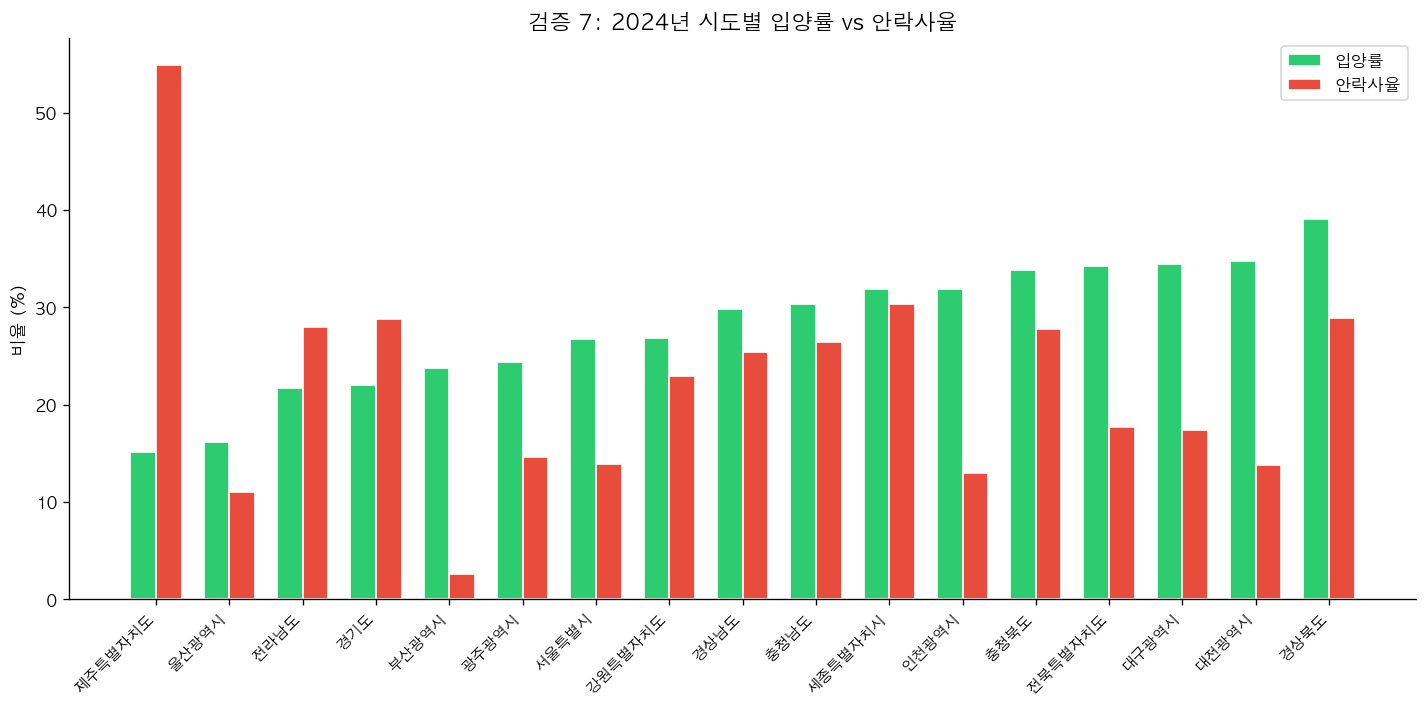

In [16]:
# 시각화: 지역별 입양률 vs 안락사율
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(region_2024))
width = 0.35

bars1 = ax.bar(x - width/2, region_2024['입양률'], width, 
               color=COLORS['입양'], label='입양률', edgecolor='white')
bars2 = ax.bar(x + width/2, region_2024['안락사율'], width,
               color=COLORS['안락사'], label='안락사율', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(region_2024['시도'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('비율 (%)')
ax.set_title('검증 7: 2024년 시도별 입양률 vs 안락사율', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../02_outputs/figures/검증7_지역별격차.png', dpi=150, bbox_inches='tight')
plt.show()

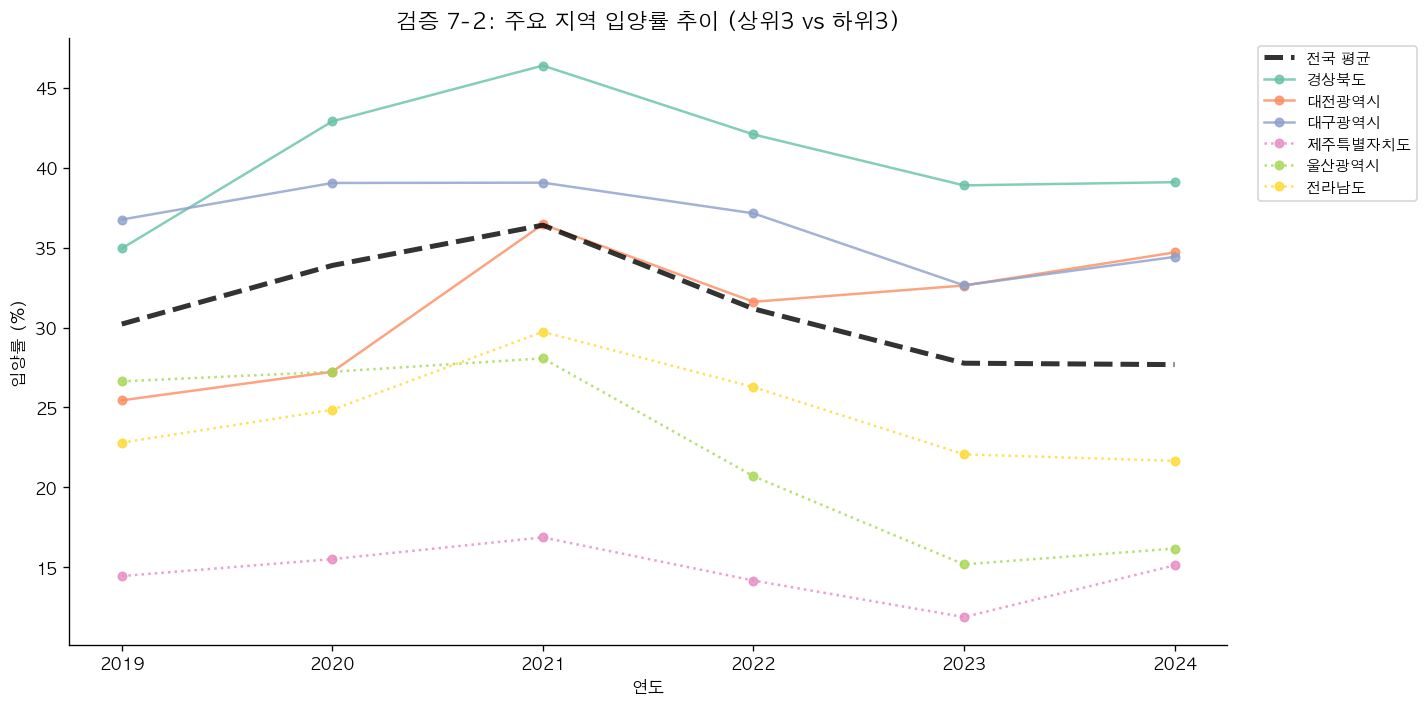

In [17]:
# 지역별 입양률 추이 (주요 지역)
fig, ax = plt.subplots(figsize=(12, 6))

# 상위/하위 지역 + 전국 평균
national = region.groupby('접수년도').apply(
    lambda x: x['입양건수'].sum() / x['총건수'].sum() * 100
).reset_index()
national.columns = ['접수년도', '입양률']

# 주요 지역 선별 (2024년 기준 상위3, 하위3)
top3 = region_2024.nlargest(3, '입양률')['시도'].tolist()
bot3 = region_2024.nsmallest(3, '입양률')['시도'].tolist()
highlight_regions = top3 + bot3

# 전국 평균
years_valid = national[national['접수년도'] <= 2024]
ax.plot(years_valid['접수년도'], years_valid['입양률'], 'k--', 
        linewidth=3, alpha=0.8, label='전국 평균', zorder=10)

# 각 지역
cmap = plt.cm.Set2
for i, sido in enumerate(highlight_regions):
    data = region[(region['시도'] == sido) & (region['접수년도'] <= 2024)]
    style = '-' if sido in top3 else ':'
    ax.plot(data['접수년도'], data['입양률'], f'o{style}', 
            color=cmap(i), linewidth=1.5, markersize=5, label=sido, alpha=0.8)

ax.set_title('검증 7-2: 주요 지역 입양률 추이 (상위3 vs 하위3)', fontsize=13, fontweight='bold')
ax.set_ylabel('입양률 (%)')
ax.set_xlabel('연도')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../02_outputs/figures/검증7_지역별추이.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 종합: 보고서 주장 검증 결과

아래 셀에서 7개 주장의 검증 결과를 정리한다.

In [18]:
print('=' * 70)
print('      보고서 주장 vs 데이터 검증 결과 종합')
print('=' * 70)

results = [
    ('1', '유기동물 5년 연속 감소', '', ''),
    ('2', '입양률 32.1%→23.5% (3년 연속 하락)', '', ''),
    ('3', '보호소 내 사망률 약 46%', '', ''),
    ('4', '축종 비중: 개 72.4% / 고양이 26.0%', '', ''),
    ('5', '믹스견·대형견 입양 소외', '', ''),
    ('6', '보호소 간 성과 극심한 격차', '', ''),
    ('7', '지역별 관리 수준 격차', '', ''),
]

# 검증 1 결과
yearly_t = region.groupby('접수년도')['총건수'].sum()
decrease_5yr = all(yearly_t.diff().dropna().loc[2020:2024] < 0)
match_count = abs(yearly_t[2024] - 106824) / 106824 * 100
results[0] = ('1', '유기동물 5년 연속 감소, 106,824마리', 
              f'데이터 {yearly_t[2024]:,.0f}마리 (차이 {match_count:.1f}%)',
              '✓' if decrease_5yr else '△')

# 검증 2 결과
adoption_trend = [pivot.loc[y, '입양'] for y in [2021, 2022, 2023, 2024]]
all_drop = all(adoption_trend[i] > adoption_trend[i+1] for i in range(len(adoption_trend)-1))
results[1] = ('2', '입양률 32.1%→23.5% (3년 연속 하락)',
              f'데이터 {pivot.loc[2021, "입양"]:.1f}%→{pivot.loc[2024, "입양"]:.1f}%',
              '✓' if all_drop else '△')

# 검증 3 결과
death_2024 = death_in_shelter.loc[2024, '합계(사망률)']
results[2] = ('3', '보호소 내 사망률 약 46%',
              f'데이터 {death_2024:.1f}%',
              '✓' if abs(death_2024 - 46) < 5 else '△')

# 검증 4 결과
results[3] = ('4', '축종: 개 72.4% / 고양이 26.0%',
              f'데이터: 개 {row_2024["개_비중"]}% / 고양이 {row_2024["고양이_비중"]}%',
              '✓' if abs(float(row_2024['개_비중']) - 72.4) < 3 else '△')

# 검증 5 결과
mix_rate = mix_row['입양률']
pure_avg = purebred['입양률'].mean()
results[4] = ('5', '믹스견·대형견 입양 소외',
              f'믹스견 {mix_rate:.1f}% vs 품종견 평균 {pure_avg:.1f}% (격차 {pure_avg-mix_rate:.1f}%p)',
              '✓')

# 검증 6 결과
gap = shelter_valid['입양률'].max() - shelter_valid['입양률'].min()
results[5] = ('6', '보호소 간 성과 극심한 격차',
              f'입양률 {shelter_valid["입양률"].min():.0f}%~{shelter_valid["입양률"].max():.0f}% (격차 {gap:.0f}%p)',
              '✓')

# 검증 7 결과
region_gap = region_2024['입양률'].max() - region_2024['입양률'].min()
results[6] = ('7', '지역별 관리 수준 격차',
              f'시도 입양률 {region_2024["입양률"].min():.1f}%~{region_2024["입양률"].max():.1f}% (격차 {region_gap:.1f}%p)',
              '✓')

print(f'\n{"#":<3} {"보고서 주장":<35} {"데이터 검증 결과":<45} {"판정"}')
print('-' * 90)
for num, claim, result, verdict in results:
    print(f'{num:<3} {claim:<35} {result:<45} {verdict}')

print('\n판정 기준: ✓ = 일치/지지  △ = 부분 일치  ✗ = 불일치')
print('\n※ 2025년 데이터는 연도 미완료로 모든 분석에서 제외함')

      보고서 주장 vs 데이터 검증 결과 종합

#   보고서 주장                              데이터 검증 결과                                     판정
------------------------------------------------------------------------------------------
1   유기동물 5년 연속 감소, 106,824마리            데이터 103,282마리 (차이 3.3%)                       ✓
2   입양률 32.1%→23.5% (3년 연속 하락)          데이터 36.4%→27.7%                               ✓
3   보호소 내 사망률 약 46%                     데이터 53.8%                                     △
4   축종: 개 72.4% / 고양이 26.0%             데이터: 개 72.1% / 고양이 25.5%                      ✓
5   믹스견·대형견 입양 소외                       믹스견 27.7% vs 품종견 평균 36.4% (격차 8.8%p)          ✓
6   보호소 간 성과 극심한 격차                     입양률 2%~93% (격차 92%p)                          ✓
7   지역별 관리 수준 격차                        시도 입양률 15.1%~39.1% (격차 24.0%p)                ✓

판정 기준: ✓ = 일치/지지  △ = 부분 일치  ✗ = 불일치

※ 2025년 데이터는 연도 미완료로 모든 분석에서 제외함
